# Import Required Libraries

Import necessary libraries such as NumPy, PIL, Torch, and the FPIInference model.

In [1]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
# Import the FPIInference model
from fpi_model import FPIInference

c:\Users\polur\miniconda3\envs\geoloc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import distill.taskflow as taskflow
import argparse
import os
from distill.configuration_file import config
from pathlib import Path

In [3]:
config_path = Path(r'D:\CrossGeoLoc_clear_version\for_us\distill\new_example_config.json').resolve()

# Load the Model from fpi_model

Load the pre-trained FPI model using the FPIInference class. You need to provide paths to the config and checkpoint files.

In [4]:
config(config_path)

In [5]:
# Paths to config and checkpoint (adjust as needed)
config_path = r'D:\CrossGeoLoc_clear_version\for_us\distill\new_example_config.json'
checkpoint_path = 'checkpoints/CvT-13-384x384-IN-22k.pth'

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize the model
fpi_model = FPIInference(config_path, checkpoint_path, device=device)
print("Model loaded successfully!")

Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: ['head.weight', 'head.bias']
Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: ['head.weight', 'head.bias']
Model loaded successfully!


# Prepare Input Data

Load UAV and satellite images. For demonstration, we'll use placeholder images or load from files.

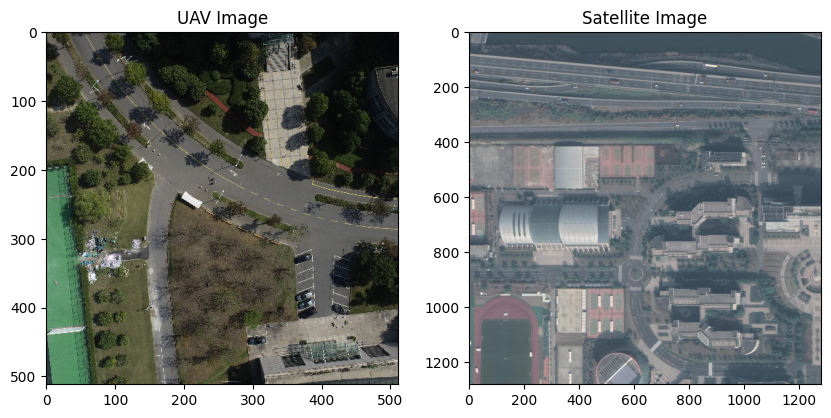

In [6]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'D:\CrossGeoLoc_clear_version\map2019\train\Caijing_000000\UAV\0.JPG'  # Example path
satellite_image_path = r'D:\CrossGeoLoc_clear_version\map2019\train\Caijing_000000\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

# Run Model Inference

Use the loaded model to predict the pixel coordinates on the satellite image corresponding to the UAV image.

In [7]:
# Run prediction
result = fpi_model.predict(uav_image, satellite_image, return_heatmap=True)

# Extract results
pixel_coord = result['pixel_coordinate']
pixel_norm = result['pixel_normalized']
heatmap = result['heatmap']

print(f"Predicted pixel coordinate: {pixel_coord}")
print(f"Normalized coordinate: {pixel_norm}")

Predicted pixel coordinate: (572, 0)
Normalized coordinate: (0.9930555555555556, 0.0)


# Display and Analyze Results

Visualize the heatmap overlay on the satellite image and analyze the prediction.

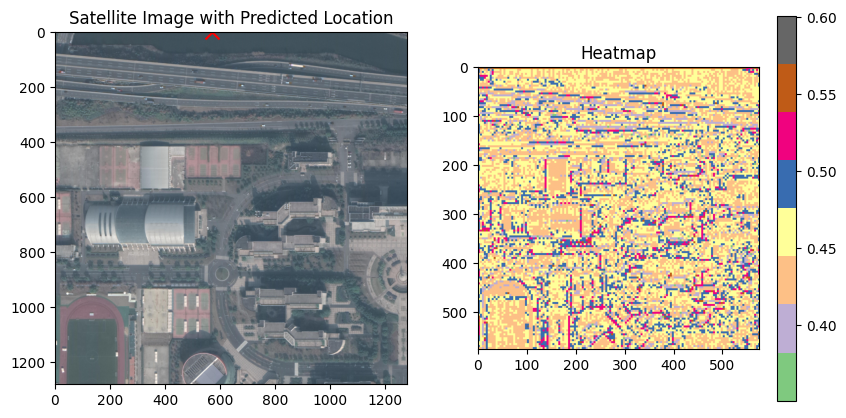

Analysis: The red X marks the predicted location of the UAV object on the satellite image.


In [8]:
# Visualize the heatmap
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(satellite_image)
plt.scatter(pixel_coord[0], pixel_coord[1], color='red', s=100, marker='x')
plt.title('Satellite Image with Predicted Location')

plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='Accent')
plt.title('Heatmap')
plt.colorbar()
plt.show()

# Additional analysis
print("Analysis: The red X marks the predicted location of the UAV object on the satellite image.")

Да работает херово, но автор прикрепил походу только часть весов 🤡🤡🤡, так что если Блек выделит компьют, то возможно что-то получится

In [9]:
mod=torch.load(r'D:\CrossGeoLoc_clear_version\for_us\checkpoints\CvT-13-384x384-IN-22k.pth',map_location='cpu')

In [10]:
mod['head.weight'].shape

torch.Size([1000, 384])

In [12]:
config(config_path).__dict__.items()

dict_items([('model', {'backbone': {'type': 'CvT', 'vit_type': 'cvt13', 'pretrain_path': 'checkpoints/CvT-13-384x384-IN-22k.pth', 'pretrain': True, 'output_index': [0, 1, 2]}, 'neck': {'type': 'CCN', 'output_dims': 384, 'UAV_output_index': [0], 'Satellite_ouput_index': 0}, 'head': {'type': 'ChannelEmbedding', 'input_ndim': 384, 'mid_process_channels': [64, 16, 1]}, 'postprocess': {'upsample_to_original': True, 'upsample_method': 'NearstUpsample', 'output_size': [576, 576]}, 'loss': {'cls_loss': {'type': 'BalanceLoss', 'center_R': 31, 'neg_weight': 130}}}), ('data_config', {'batchsize': 8, 'num_worker': 0, 'val_batchsize': 8, 'train_dir': 'D:/CrossGeoLoc_clear_version/map2019/train', 'val_dir': 'D:/CrossGeoLoc_clear_version/map2019/val', 'test_dir': 'D:/CrossGeoLoc_clear_version/map2019/train', 'test_mode': 'merge_test_700-1800_cr0.95_stride100', 'UAVhw': [192, 192], 'Satellitehw': [576, 576]}), ('pipline_config', {'train_pipeline': {'UAV': {'RandomErasing': {'probability': 0.3}, 'Rando